## imports and settings

In [1]:
import pandas as pd
import numpy as np
import requests
import itertools
import ast

from pathlib import Path
from nltk.stem import SnowballStemmer
from bs4 import BeautifulSoup

# use this for py file
# repoP = Path(__file__).resolve().parent.parent

# for notebook
repoP = Path.cwd().parent

germanWorksP = repoP / "data/german-works"

## read csv file as DF

In [9]:
similarityDF = pd.read_csv(repoP / "data/similarity/author-similarity_jaccard.csv", names=["Author_A", "Author_B", "Similarity"])

In [10]:
similarityDF.info()

<class 'pandas.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Author_A    91 non-null     str    
 1   Author_B    91 non-null     str    
 2   Similarity  91 non-null     float64
dtypes: float64(1), str(2)
memory usage: 2.3 KB


In [11]:
similarityDF.describe()

,Similarity
count,91.000000
mean,0.212491
std,0.033786
min,0.147800
25%,0.184300
50%,0.206800
75%,0.236600
max,0.292200


In [12]:
similarityDF.sample()

,Author_A,Author_B,Similarity
87,Schiller,Wieland,0.2874


## assignment 1

Entwickeln Sie ein eigenes Python-Skript, das die 10 Paare von Werken ermittelt, die die höchste Jaccard-Ähnlichkeit aufweisen. Geben Sie für jedes der zehn Paare die Namen der Werke sowie die zugehörigen Autoren und den berechneten Jaccard-Ähnlichkeitswert aus. Beim Vergleich sollen auch Paare von Werken desselben Autors berücksichtigt werden.

### get everything in a DF first

In [38]:
toDFdict = {
    "author": [],
    "workId": [],
    "work_tokenList": [],
    "work_termList": []
}

# set stemmer
stemmer = SnowballStemmer("german")

# get folders for authors
authorFolderPs = [p for p in germanWorksP.iterdir() if p.is_dir()]

# iterate through them
for authorFolderP in authorFolderPs:

    # get .tokens files and iterate through them
    for tokenFile in authorFolderP.glob("*.tokens"):

        # open every single one
        with open(tokenFile, encoding="utf-8") as tf:

            # get tokes as list
            tokenList = tokenFile.read_text().split("\n")   # read file content as string and split at newline chars

            # create term set from that list (use stemmer because why not)
            termSet = set()
            for token in tokenList:
                token = stemmer.stem(token.strip())
                if token:
                    termSet.add(token)

            # cast to list
            termList = list(termSet)

            # now create row in DF
            toDFdict["author"].append(authorFolderP.name)
            toDFdict["workId"].append(tokenFile.name.replace(".tokens", ""))
            toDFdict["work_tokenList"].append(tokenList)
            toDFdict["work_termList"].append(termList)

# create DF from dict            
dataDF = pd.DataFrame.from_dict(toDFdict)

In [39]:
dataDF.head()

,author,workId,work_tokenList,work_termList
0,Fontane,26686,"[produced, markus, brenner, online, distribute...","[montmirail, frei, prompt, weinkell, malt, lie..."
1,Fontane,36905,"[produced, jana, srna, norbert, langkau, onlin...","[frei, bemerkenswerth, versicher, nachgegeb, b..."
2,Fontane,46184,"[anmerkungen, transkription, rechtschreibung, ...","[frei, malt, instinktiv, versicher, abwag, bes..."
3,Fontane,47311,"[anmerkungen, transkription, original, gesperr...","[frei, malt, varnhag, vierhundertjahr, versich..."
4,Fontane,52912,"[anmerkungen, transkription, original, fraktur...","[frei, beunruhigt, versicher, kanevas, nachgeg..."


In [30]:
# quick manual check with file

assert len(dataDF.iloc[0]["work_tokenList"]) == 20416 # lookup in data/german-works/Fontane/26686.tokens

### fetch and enrich workLabel

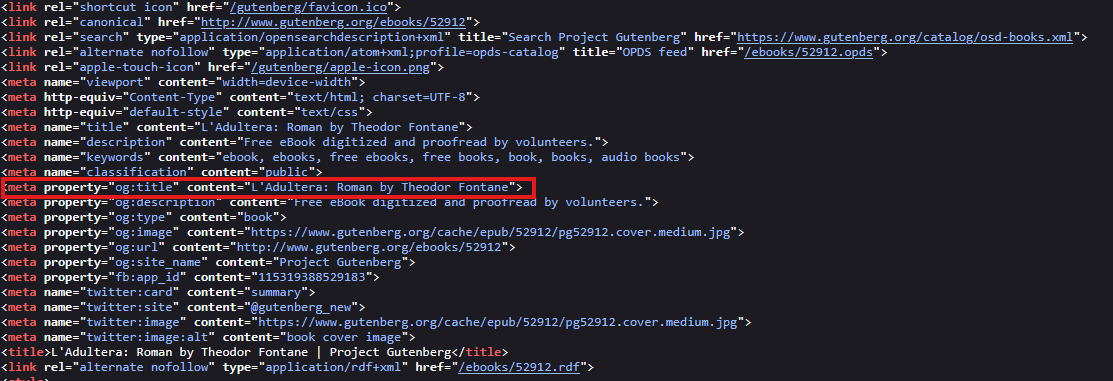

In [40]:
def fetchWorkLabel(workId: str) -> list[str | None, str | None]:

    # create url
    url = f"https://www.gutenberg.org/ebooks/{workId}"

    try:
        print(f"Fetching workLabel for workId {workId}.")

        # get request
        res = session.get(url)
        res.raise_for_status()

        # get and parse html
        labelSoup = BeautifulSoup(res.text, "html.parser")

        # get meta tag
        metaTag = labelSoup.find("meta", attrs={"name": "title"})

        if metaTag:
            titleLabel = metaTag["content"]

            print(f"Resulting label: {titleLabel}")
            return [titleLabel, None]

        else:
            print("FetchError: Error while fetching title from according meta tag.")
            return [None, "FetchError: Error while fetching title from according meta tag."]

    except Exception as e:
        print(f"FetchError: {e}.")
        return [None, f"FetchError: {e}."]

In [41]:
# use single session to reduce overhead
with requests.Session() as session:

    # apply function to column, use .apply(pd.Series) to split list into individual columns
    expandedColsDF = dataDF["workId"].apply(fetchWorkLabel).apply(pd.Series)

    # rename newly generated columns
    expandedColsDF.columns = ["workLabel", "fetchError"]

    # join back to original DataFrame
    dataDF = dataDF.join(expandedColsDF)

Fetching workLabel for workId 26686.
Resulting label: Unterm Birnbaum by Theodor Fontane
Fetching workLabel for workId 36905.
Resulting label: Schach von Wuthenow by Theodor Fontane
Fetching workLabel for workId 46184.
Resulting label: Frau Jenny Treibel: Roman aus der Berliner Gesellschaft by Theodor Fontane
Fetching workLabel for workId 47311.
Resulting label: Wanderungen durch die Mark Brandenburg, Dritter Teil by Theodor Fontane
Fetching workLabel for workId 52912.
Resulting label: L'Adultera: Roman by Theodor Fontane
Fetching workLabel for workId 5323.
Resulting label: Effi Briest by Theodor Fontane
Fetching workLabel for workId 53628.
Resulting label: Der Stechlin: Roman by Theodor Fontane
Fetching workLabel for workId 75277.
Resulting label: Kriegsgefangen :  Erlebtes 1870. by Theodor Fontane
Fetching workLabel for workId 10353.
Resulting label: Satyros oder Der vergötterte Waldteufel by Johann Wolfgang von Goethe
Fetching workLabel for workId 10354.
Resulting label: Die Laune d

In [46]:
# quick check if every work now has a workLabel

dataDF[dataDF["workLabel"].isna()]

,author,workId,work_tokenList,work_termList,workLabel


In [43]:
# check for fetchErrors

dataDF[dataDF["fetchError"].notna()]

,author,workId,work_tokenList,work_termList,workLabel,fetchError


In [44]:
# no errors - get rid of column

dataDF = dataDF.drop(columns=["fetchError"])

In [ ]:
# out of curiosity: the " by " in workLabel seems suspicious.. is it in every workLabel?

dataDF[dataDF["workLabel"].str.contains(" by ")]

,author,workId,work_tokenList,work_termList,workLabel
0,Fontane,26686,"[produced, markus, brenner, online, distribute...","[montmirail, frei, prompt, weinkell, malt, lie...",Unterm Birnbaum by Theodor Fontane
1,Fontane,36905,"[produced, jana, srna, norbert, langkau, onlin...","[frei, bemerkenswerth, versicher, nachgegeb, b...",Schach von Wuthenow by Theodor Fontane
2,Fontane,46184,"[anmerkungen, transkription, rechtschreibung, ...","[frei, malt, instinktiv, versicher, abwag, bes...",Frau Jenny Treibel: Roman aus der Berliner Ges...
3,Fontane,47311,"[anmerkungen, transkription, original, gesperr...","[frei, malt, varnhag, vierhundertjahr, versich...","Wanderungen durch die Mark Brandenburg, Dritte..."
4,Fontane,52912,"[anmerkungen, transkription, original, fraktur...","[frei, beunruhigt, versicher, kanevas, nachgeg...",L'Adultera: Roman by Theodor Fontane
...,...,...,...,...,...
197,Twain,66952,"[anmerkungen, transkription, original, fraktur...","[frei, malt, ehegatt, beunruhigt, schurkerei, ...",Wie Hadleyburg verderbt wurde: Nebst anderen E...
198,Wieland,2187,"[this, etext, prepared, michael, pullen, globa...","[schlafend, nithart, versicher, jugendlicht, b...",Oberon by Christoph Martin Wieland
199,Wieland,2313,"[this, etext, prepared, michael, pullen, alpha...","[frei, ausbrutet, malt, schlafend, beunruhigt,...",Geschichte des Agathon. Teil 1 by Christoph Ma...
200,Wieland,2314,"[this, etext, prepared, michael, pullen, alpha...","[frei, heuchelei, malt, schlafend, versicher, ...",Geschichte des Agathon. Teil 2 by Christoph Ma...


In [49]:
# no not in every one -> these two do not contain " by "

dataDF[~dataDF["workLabel"].str.contains(" by ")]

,author,workId,work_tokenList,work_termList,workLabel
84,Humboldt,22659,"[rede, gehalten, eröffnung, versammlung, deuts...","[frei, bestimmt, bearbeit, durchlauft, schritt...","Rede, gehalten bei der Eröffnung der Versammlu..."
102,Kant,38295,"[produced, norbert, langkau, jana, srna, onlin...","[offensicht, schritt, ausbricht, bestand, auff...","Von der Macht des Gemüts, durch den bloßen Vor..."


In [50]:
# in detail:
print(dataDF.iloc[84]["workLabel"])
print(dataDF.iloc[102]["workLabel"])

Rede, gehalten bei der Eröffnung der Versammlung deutscher Naturforscher und…
Von der Macht des Gemüts, durch den bloßen Vorsatz seiner krankhaften Gefühle…


### base analyses

In [96]:
# duplicates?
dataDF[dataDF["workId"].duplicated(keep=False)]

,author,workId,work_tokenList,work_termList,workLabel,work_termCount,uniqueWorkId
45,Goethe,31216,"[produced, karl, eichwalder, jana, srna, onlin...","[realitat, bewundert, widerruf, bearbeit, abtr...",Briefe Schillers und Goethes an A. W. Schlegel...,2073,312160
152,Schiller,31216,"[produced, karl, eichwalder, jana, srna, onlin...","[realitat, bewundert, widerruf, bearbeit, abtr...",Briefe Schillers und Goethes an A. W. Schlegel...,2073,312161


In [95]:
# this needs some refining -> keep workId and set "uniqueWorkId" - Goethe will get 0 appended, Schiller will get 1 appended

dataDF["uniqueWorkId"] = dataDF["workId"]
dataDF.loc[45, "uniqueWorkId"] = "312160"
dataDF.loc[152, "uniqueWorkId"] = "312161"

In [52]:
# authors with the most books

dataDF["author"].value_counts()

author
Goethe      49
Hesse       20
Lessing     18
Storm       18
Schiller    15
Twain       13
Kant        12
Kafka       11
Mann        11
Rilke       11
Fontane      8
Heine        6
Humboldt     6
Wieland      4
Name: count, dtype: int64

In [ ]:
# works with the most terms by author count desc

dataDF["work_termCount"] = dataDF["work_termList"].apply(lambda x: len(x))
dataDF.sort_values(by=["author", "work_termCount"], ascending=[True, False])

,author,workId,work_tokenList,work_termList,workLabel,work_termCount
3,Fontane,47311,"[anmerkungen, transkription, original, gesperr...","[frei, malt, varnhag, vierhundertjahr, versich...","Wanderungen durch die Mark Brandenburg, Dritte...",15458
6,Fontane,53628,"[anmerkungen, transkription, original, fraktur...","[frei, heuchelei, malt, naturwuchs, beunruhigt...",Der Stechlin: Roman by Theodor Fontane,10743
5,Fontane,5323,"[produced, this, ebook, prepared, gunther, ole...","[frei, abtrocknet, dusig, strandsand, beunruhi...",Effi Briest by Theodor Fontane,8062
7,Fontane,75277,"[anmerkungen, transkription, original, fraktur...","[frei, kaleidoskop, schlafend, tupft, beunruhi...",Kriegsgefangen : Erlebtes 1870. by Theodor Fo...,7564
2,Fontane,46184,"[anmerkungen, transkription, rechtschreibung, ...","[frei, malt, instinktiv, versicher, abwag, bes...",Frau Jenny Treibel: Roman aus der Berliner Ges...,6866
...,...,...,...,...,...,...
192,Twain,65346,"[anmerkungen, transkription, original, fraktur...","[frei, malt, bestand, ortszeit, binn, ausfrag,...",Tom Sawyers Neue Abenteuer by Mark Twain,5637
198,Wieland,2187,"[this, etext, prepared, michael, pullen, globa...","[schlafend, nithart, versicher, jugendlicht, b...",Oberon by Christoph Martin Wieland,7103
199,Wieland,2313,"[this, etext, prepared, michael, pullen, alpha...","[frei, ausbrutet, malt, schlafend, beunruhigt,...",Geschichte des Agathon. Teil 1 by Christoph Ma...,6371
200,Wieland,2314,"[this, etext, prepared, michael, pullen, alpha...","[frei, heuchelei, malt, schlafend, versicher, ...",Geschichte des Agathon. Teil 2 by Christoph Ma...,5998


### export and import dataDF

#### export

In [97]:
dataDF.to_csv(repoP / "docs/assignment/baseData.csv", index=False)

#### import

In [14]:
dataDF = pd.read_csv(repoP / "docs/assignment/baseData.csv", dtype=str)

dataDF["work_termCount"] = dataDF["work_termCount"].astype(int)

# bring back native py data types
dataDF["work_tokenList"] = dataDF["work_tokenList"].apply(lambda x: ast.literal_eval(x))
dataDF["work_termList"] = dataDF["work_termList"].apply(lambda x: ast.literal_eval(x))

In [15]:
# quick check

type(dataDF.iloc[0]["work_termList"])

list

In [18]:
dataDF.sample()

,author,workId,work_tokenList,work_termList,workLabel,work_termCount,uniqueWorkId
29,Goethe,2338,"[this, etext, prepared, michael, pullen, globa...","[frei, soldatenstand, liebt, verfehlt, freut, ...",Wilhelm Meisters Lehrjahre — Band 4 by Johann ...,3774,2338


### calculate jaccard similarity for all work combinations

In [4]:
# use itertools.combinations to create unique pairs of workIds (order does not matter, no self-pairs)
pairs = list(itertools.combinations(list(dataDF["uniqueWorkId"]), 2))

# create DF from that
jaccardDF = pd.DataFrame(pairs, columns=["work_A", "work_B"])

In [5]:
jaccardDF

,work_A,work_B
0,26686,36905
1,26686,46184
2,26686,47311
3,26686,52912
4,26686,5323
...,...,...
20296,2187,2314
20297,2187,46580
20298,2313,2314
20299,2313,46580


In [6]:
# re-use from script `06_compute-author-similarity.py`

def compute_similarity(terms_A, terms_B, mode="jaccard"):
    """
    Berechnet die Ähnlichkeit zwischen zwei Autoren basierend auf den zugehörigen Term-Mengen ihrer Werke.

    Parameter:
    - terms_A: Menge der Terme aus den Werken des ersten Autors
    - terms_B: Menge der Terme aus den Werken des zweiten Autors
    - mode: Modus der Ähnlichkeitsberechnung ("jaccard", "dice", "otsuka-ochiai")
    """
    intersection = terms_A & terms_B # Schnittmenge der Term-Mengen beider Autoren
    if mode == "jaccard":
        union = terms_A | terms_B # Vereinigungsmenge der Term-Mengen beider Autoren
        similarity = len(intersection) / len(union) if union else 0
    elif mode == "dice":
        # bietet sich an, wenn die beiden Term-Mengen sehr unterschiedlich groß sind (Normierung der Größe der
        # Schnittmenge durch das arithmetische Mittel der Größen der beiden Term-Mengen)
        len_arithmetic_mean = 0.5 * (len(terms_A) + len(terms_B))
        similarity = len(intersection) / len_arithmetic_mean if len_arithmetic_mean > 0 else 0
    elif mode == "otsuka-ochiai":
        # bietet sich an, wenn die beiden Term-Mengen sehr unterschiedlich groß sind (Normierung der Größe der
        # Schnittmenge durch das geometrische Mittel der Größen der beiden Term-Mengen)
        len_geom_mean = (len(terms_A) * len(terms_B)) ** 0.5
        similarity = len(intersection) / len_geom_mean if len_geom_mean > 0 else 0
    else:
        similarity = 0

    # return similarity:.4f
    return similarity


# little wrapper
def wrapCompSim(workId_A: str, workId_B: str) -> float:

    # get terms from dataDF via uniqueWorkId
    terms_A = set(dataDF[dataDF["uniqueWorkId"] == workId_A].iloc[0]["work_termList"])
    terms_B = set(dataDF[dataDF["uniqueWorkId"] == workId_B].iloc[0]["work_termList"])

    # call base function
    similarity = compute_similarity(terms_A, terms_B)

    return similarity

In [7]:
# apply function to jaccardDF

jaccardDF["jaccardSimilarity"] = jaccardDF.apply(lambda row: wrapCompSim(row["work_A"], row["work_B"]), axis=1)

In [105]:
jaccardDF

,work_A,work_B,jaccardSimilarity
0,26686,36905,0.235789
1,26686,46184,0.221319
2,26686,47311,0.153085
3,26686,52912,0.225814
4,26686,5323,0.219135
...,...,...,...
20296,2187,2314,0.220969
20297,2187,46580,0.204364
20298,2313,2314,0.415541
20299,2313,46580,0.258627


### export and import jaccardDF

#### export

In [8]:
jaccardDF.to_csv(repoP / "docs/assignment/jaccardSimilarityData.csv", index=False)

#### import

In [19]:
jaccardDF = pd.read_csv(repoP / "docs/assignment/jaccardSimilarityData.csv", dtype=str)

jaccardDF["jaccardSimilarity"] = jaccardDF["jaccardSimilarity"].astype(float)

In [20]:
type(jaccardDF.iloc[0]["jaccardSimilarity"])

numpy.float64

In [21]:
jaccardDF

,work_A,work_B,jaccardSimilarity
0,26686,36905,0.235789
1,26686,46184,0.221319
2,26686,47311,0.153085
3,26686,52912,0.225814
4,26686,5323,0.219135
...,...,...,...
20296,2187,2314,0.220969
20297,2187,46580,0.204364
20298,2313,2314,0.415541
20299,2313,46580,0.258627


### print top10 (assignment solution)

In [23]:
# now to the assignment: top 10 pairs with the highest jaccardSimilarity, also workLabel and authors

# order DF first:
jaccardDF = jaccardDF.sort_values(by="jaccardSimilarity", ascending=False)
jaccardDF = jaccardDF.reset_index(drop=True)

In [24]:
# order DF first:
top10DF = jaccardDF.head(10)

print("===================================================================")
print("TOP 10 SIMILAR WORKS")
print("===================================================================\n\n")

for idx, row in top10DF.iterrows():

    print("===================================================================")
    print(f"TOP {idx + 1} - SIMILARITY SCORE: {row["jaccardSimilarity"]}")
    print("-------------------------------------------------------------------")
    print("WORK A")
    print(f"Unique WorkId: {row["work_A"]}")
    print(f"Original WorkId: {dataDF[dataDF["uniqueWorkId"] == row["work_A"]].iloc[0]["workId"]}")
    print(f"Work Label: {dataDF[dataDF["uniqueWorkId"] == row["work_A"]].iloc[0]["workLabel"]}")
    print(f"Author: {dataDF[dataDF["uniqueWorkId"] == row["work_A"]].iloc[0]["author"]}")
    print("-------------------------------------------------------------------")
    print("WORK B")
    print(f"Unique WorkId: {row["work_B"]}")
    print(f"Original WorkId: {dataDF[dataDF["uniqueWorkId"] == row["work_B"]].iloc[0]["workId"]}")
    print(f"Work Label: {dataDF[dataDF["uniqueWorkId"] == row["work_B"]].iloc[0]["workLabel"]}")
    print(f"Author: {dataDF[dataDF["uniqueWorkId"] == row["work_B"]].iloc[0]["author"]}")
    print("===================================================================\n")
    


TOP 10 SIMILAR WORKS


TOP 1 - SIMILARITY SCORE: 1.0
-------------------------------------------------------------------
WORK A
Unique WorkId: 312160
Original WorkId: 31216
Work Label: Briefe Schillers und Goethes an A. W. Schlegel by Schiller and Goethe
Author: Goethe
-------------------------------------------------------------------
WORK B
Unique WorkId: 312161
Original WorkId: 31216
Work Label: Briefe Schillers und Goethes an A. W. Schlegel by Schiller and Goethe
Author: Schiller

TOP 2 - SIMILARITY SCORE: 0.9603616133518776
-------------------------------------------------------------------
WORK A
Unique WorkId: 5325
Original WorkId: 5325
Work Label: Römische Elegien by Johann Wolfgang von Goethe
Author: Goethe
-------------------------------------------------------------------
WORK B
Unique WorkId: 7875
Original WorkId: 7875
Work Label: Römische Elegien by Johann Wolfgang von Goethe
Author: Goethe

TOP 3 - SIMILARITY SCORE: 0.8677971424085413
-------------------------------------